# Step 1

In [92]:
!pip install ucimlrepo


In [93]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    LogisticRegression
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [94]:
forest_fires = fetch_ucirepo(id=162)

X = forest_fires.data.features
y = forest_fires.data.targets

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0



Target:


,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [95]:
print(X.info())


<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None


In [96]:
print(X.describe())


                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain  
count  517.000000  517.000000  517.000000  517.000000  
mean    18.889168   44.288201    4.017602    0.021663  
std      5.806625   16.317469    1.791653    0.295959  
min      2.200000   15.000000    0.400000    0

In [97]:
print(y.head())

   area
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0


# Step 2- EDA

In [98]:
# Display the target variable
print("Target variable:")
print(y.head())


Target variable:
   area
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0


In [99]:

# Summary statistics for fire area
print("\nSummary statistics for fire area:")
print(y.describe())



Summary statistics for fire area:
              area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000


In [100]:

# Count zero-area fires
zero_fires = (y["area"] == 0).sum()

print(f"\nNumber of fires with zero burned area: {zero_fires}")
print(f"Percentage of zero-area observations: {zero_fires / len(y) * 100:.2f}%")


Number of fires with zero burned area: 247
Percentage of zero-area observations: 47.78%


- The area variable represents the burned area of the forest.

- This dataset shows that many observations have an area of 0. Meaning the distribution is heavily skewed.

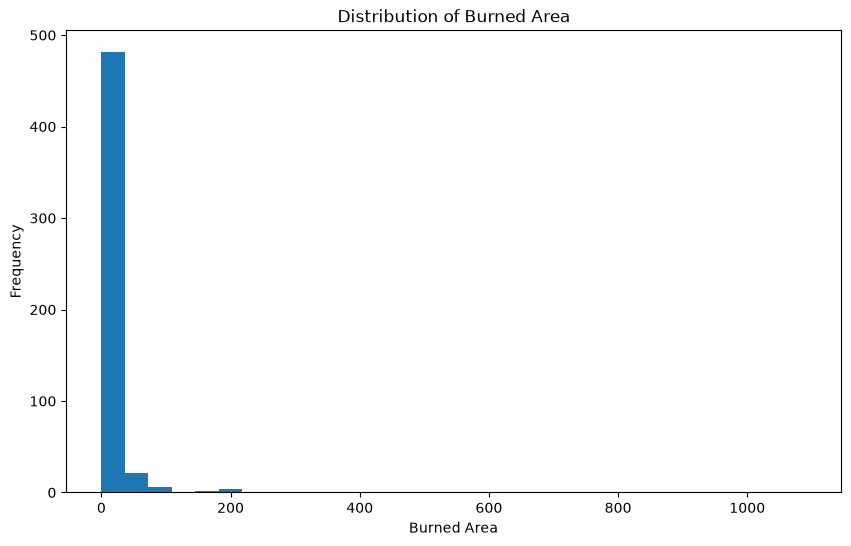

In [101]:
# Histogram showing the distribution of fire area

plt.figure(figsize=(10, 6))
plt.hist(y["area"], bins=30)
plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.title("Distribution of Burned Area")
plt.show()

- The target is strongly right-skewed, with many fires having relatively small burned areas and a smaller number of very large fires

In [102]:
# Examine the predictors (features and target variable)
X.describe(include="all")

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,517.000000,517.000000,517,517,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
unique,NaN,NaN,12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,aug,sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,184,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.669246,4.299807,NaN,NaN,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663
std,2.313778,1.229900,NaN,NaN,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959
min,1.000000,2.000000,NaN,NaN,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,NaN,NaN,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,NaN,NaN,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000
75%,7.000000,5.000000,NaN,NaN,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000


In [103]:
# Unique values for categorical variables
print("Months:")
print(X["month"].unique())

print("\nDays:")
print(X["day"].unique())

Months:
<StringArray>
['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan', 'dec', 'may',
 'nov']
Length: 12, dtype: str

Days:
<StringArray>
['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu']
Length: 7, dtype: str


In [104]:
# Conversion of the target to a DataFrame
df = X.copy()

df["area"] = y["area"]

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [105]:
# Correlation analysis
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

print(correlation["area"].sort_values(ascending=False))

area    1.000000
temp    0.097844
DMC     0.072994
X       0.063385
DC      0.049383
Y       0.044873
FFMC    0.040122
wind    0.012317
ISI     0.008258
rain   -0.007366
RH     -0.075519
Name: area, dtype: float64


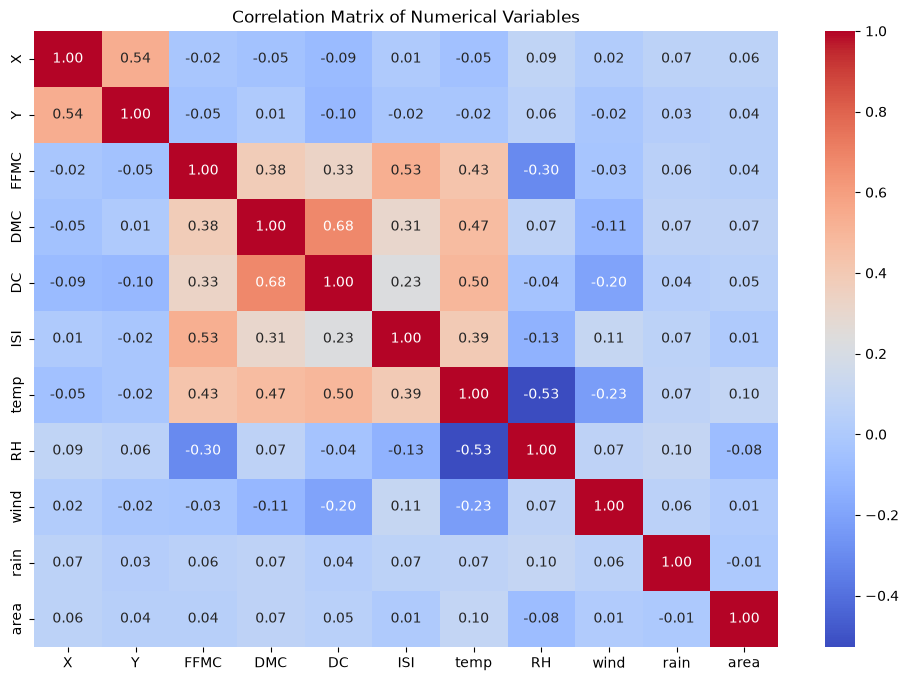

In [106]:
# correlation heatmap


plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Correlation Findings

The correlation matrix was used to identify linear relationships between the environmental variables and fire size.

The results show that there were no environmental variables that have meaningful linear relationship with `log_area`. The strongest absolute correlations were negligible: DMC and DC (both at +0.07), followed by RH at -0.05. Suggesting that fire size is not driven by simple linear trends.

Since correlation does not establish causation, these relationships will be evaluated further through modelling to capture potential threshold effects and interactions between variables.

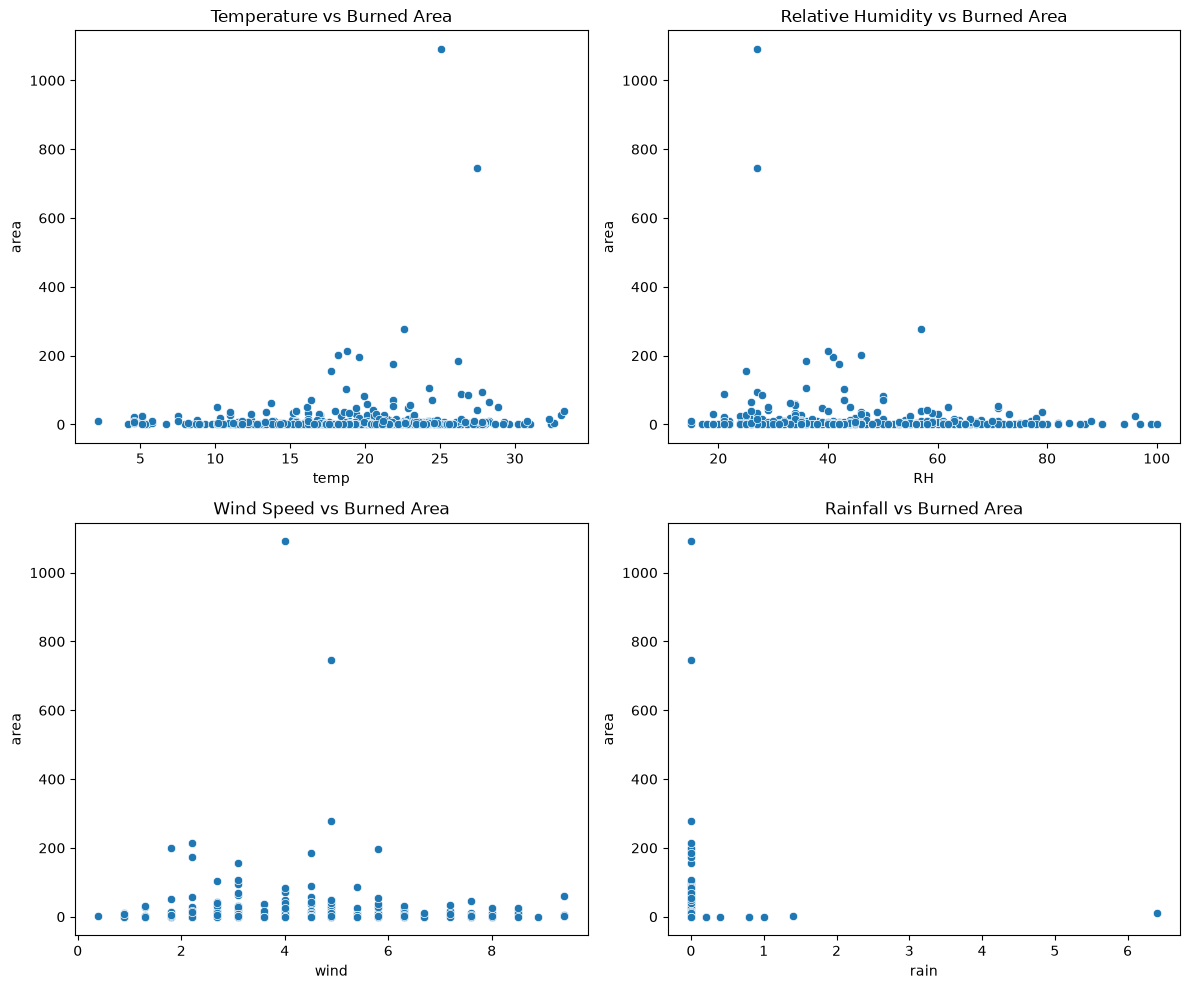

In [107]:
# Scatter plots for numerical variables against the target variable
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=df, x="temp", y="area", ax=axes[0, 0])
axes[0, 0].set_title("Temperature vs Burned Area")

sns.scatterplot(data=df, x="RH", y="area", ax=axes[0, 1])
axes[0, 1].set_title("Relative Humidity vs Burned Area")

sns.scatterplot(data=df, x="wind", y="area", ax=axes[1, 0])
axes[1, 0].set_title("Wind Speed vs Burned Area")

sns.scatterplot(data=df, x="rain", y="area", ax=axes[1, 1])
axes[1, 1].set_title("Rainfall vs Burned Area")

plt.tight_layout()
plt.show()

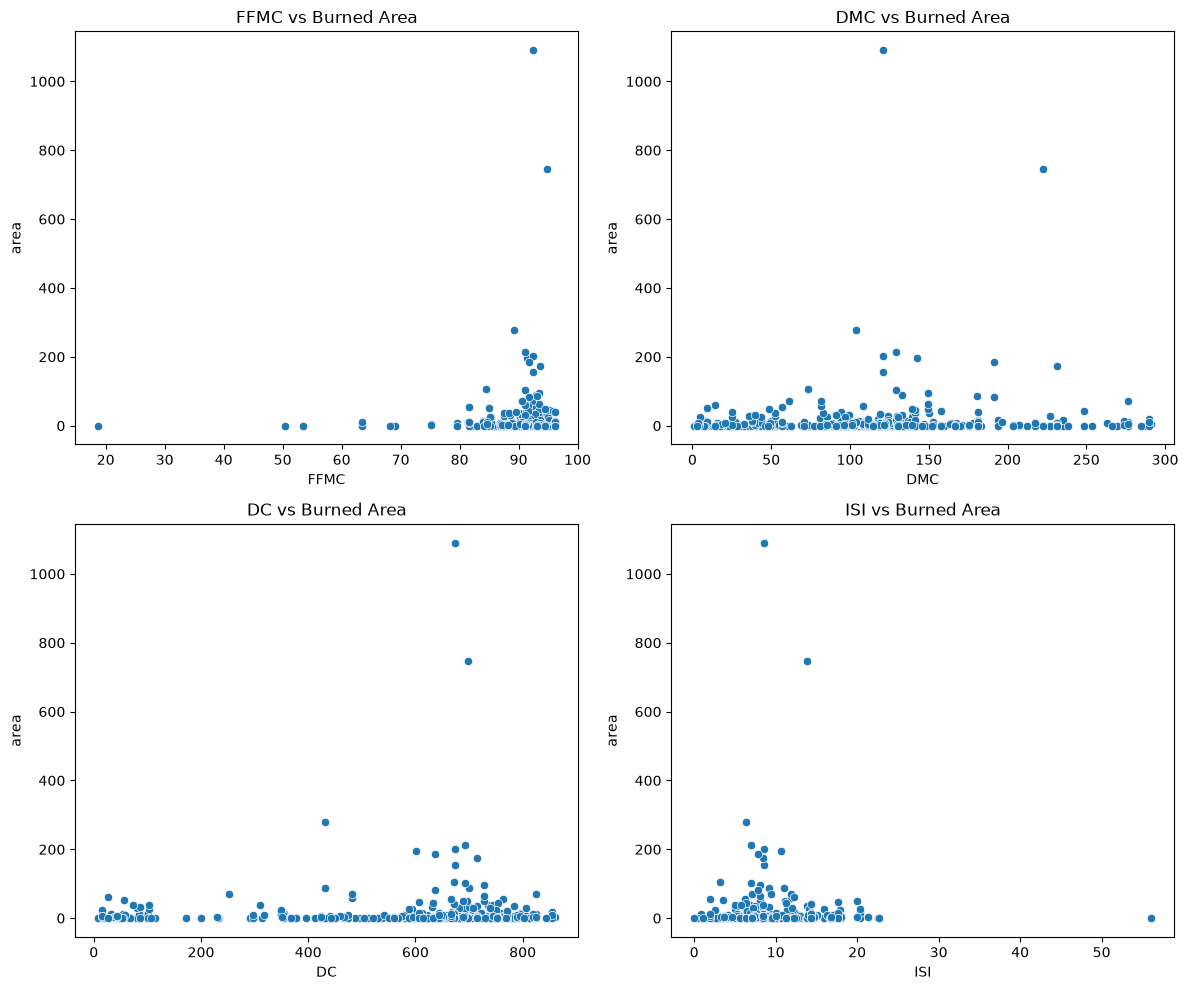

In [108]:
# Scatter plots for numerical variables against the target variable (Fire weather indices)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=df, x="FFMC", y="area", ax=axes[0, 0])
axes[0, 0].set_title("FFMC vs Burned Area")

sns.scatterplot(data=df, x="DMC", y="area", ax=axes[0, 1])
axes[0, 1].set_title("DMC vs Burned Area")

sns.scatterplot(data=df, x="DC", y="area", ax=axes[1, 0])
axes[1, 0].set_title("DC vs Burned Area")

sns.scatterplot(data=df, x="ISI", y="area", ax=axes[1, 1])
axes[1, 1].set_title("ISI vs Burned Area")

plt.tight_layout()
plt.show()

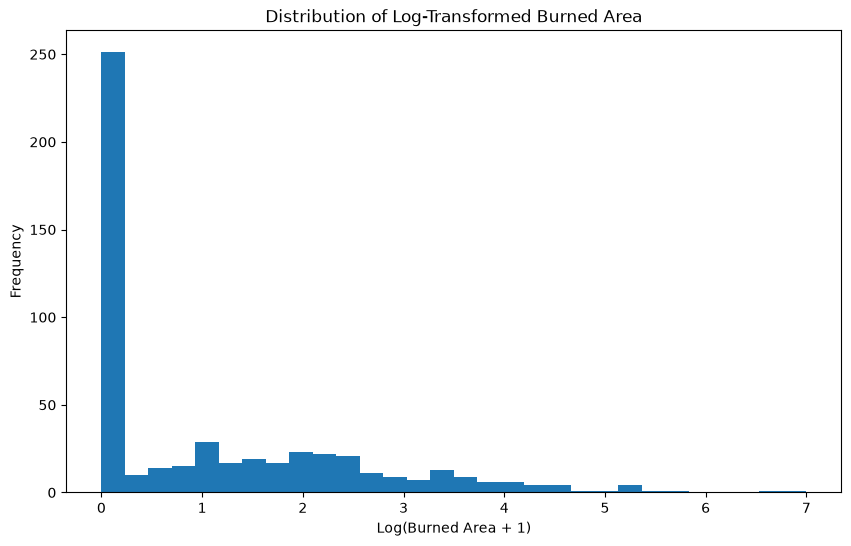

In [109]:

# Log transformation of the target variable

df["log_area"] = np.log1p(df["area"])

plt.figure(figsize=(10, 6))

plt.hist(df["log_area"], bins=30)

plt.xlabel("Log(Burned Area + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Burned Area")

plt.show()

#### Target distribution

- The original fire-area variable is strongly right-skewed, indicating that most observations correspond to relatively small fires while a small number of observations represent larger fires.

- A log transformation reduces the influence of extreme observations and produces a more balanced target distribution. Hence, the transformed target will be used for regression analysis.

# Step 3

In [126]:
# Create a modelling dataframe
model_df = X.copy()

# Add the target variable
model_df["area"] = y["area"]

# Log-transform the target because fire area is highly right-skewed
model_df["log_area"] = np.log1p(model_df["area"])

# Convert categorical variables into dummy variables
model_df = pd.get_dummies(
    model_df,
    columns=["month", "day"],
    drop_first=True,
    dtype=int
)

# Log-transform highly right-skewed predictors
model_df["log_rain"] = np.log1p(model_df["rain"])
model_df["log_ISI"] = np.log1p(model_df["ISI"])

# Add quadratic terms to capture nonlinear relationships
model_df["temp_squared"] = model_df["temp"] ** 2
model_df["wind_squared"] = model_df["wind"] ** 2

# Add interaction terms
model_df["temp_RH_interaction"] = (
    model_df["temp"] * model_df["RH"]
)

model_df["wind_FFMC_interaction"] = (
    model_df["wind"] * model_df["FFMC"]
)

# Display the first few rows
model_df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,day_sun,day_thu,day_tue,day_wed,log_rain,log_ISI,temp_squared,wind_squared,temp_RH_interaction,wind_FFMC_interaction
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,0.000000,1.808289,67.24,44.89,418.2,577.54
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,1,0,0.000000,2.041220,324.00,0.81,594.0,81.54
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0.000000,2.041220,213.16,1.69,481.8,117.78
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,0.182322,2.302585,68.89,16.00,805.1,366.80
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,1,0,0,0,0.000000,2.360854,129.96,3.24,1128.6,160.74


In [134]:
# Define the original predictors for the baseline model
baseline_features = [
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain"
]

X_baseline = model_df[baseline_features]
y_model = model_df["log_area"]

# Split the baseline data into training and testing sets
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline,
    y_model,
    test_size=0.20,
    random_state=42
)

# Create and fit the baseline multiple linear regression model
baseline_model = LinearRegression()

baseline_model.fit(
    X_train_base,
    y_train_base
)

# Make predictions
baseline_pred = baseline_model.predict(X_test_base)

# Evaluate the baseline model
baseline_mse = mean_squared_error(
    y_test_base,
    baseline_pred
)

baseline_r2 = r2_score(
    y_test_base,
    baseline_pred
)

print("Baseline Regression Model")
print(f"MSE: {baseline_mse:.4f}")
print(f"R²: {baseline_r2:.4f}")

Baseline Regression Model
MSE: 2.1911
R²: 0.0031


In [128]:
# Separate predictors and target for the improved model

X_model = model_df.drop(
    columns=["area", "log_area"]
)

y_model = model_df["log_area"]

print("Predictors:", X_model.shape)
print("Target:", y_model.shape)

Predictors: (517, 33)
Target: (517,)


In [129]:
# Split the improved model data

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (413, 33)
Testing set: (104, 33)


In [132]:
# Create and fit the improved multiple linear regression model

improved_model = LinearRegression()

improved_model.fit(
    X_train,
    y_train
)

# Make predictions on the test set
y_pred = improved_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Improved Regression Model")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

Improved Regression Model
MSE: 2.3878
R²: -0.0864


In [133]:
# Compare the baseline and improved models

print("Model Comparison")
print(f"Baseline MSE:  {baseline_mse:.4f}")
print(f"Improved MSE:  {mse:.4f}")
print()
print(f"Baseline R²:   {baseline_r2:.4f}")
print(f"Improved R²:   {r2:.4f}")

Model Comparison
Baseline MSE:  2.1911
Improved MSE:  2.3878

Baseline R²:   0.0031
Improved R²:   -0.0864
